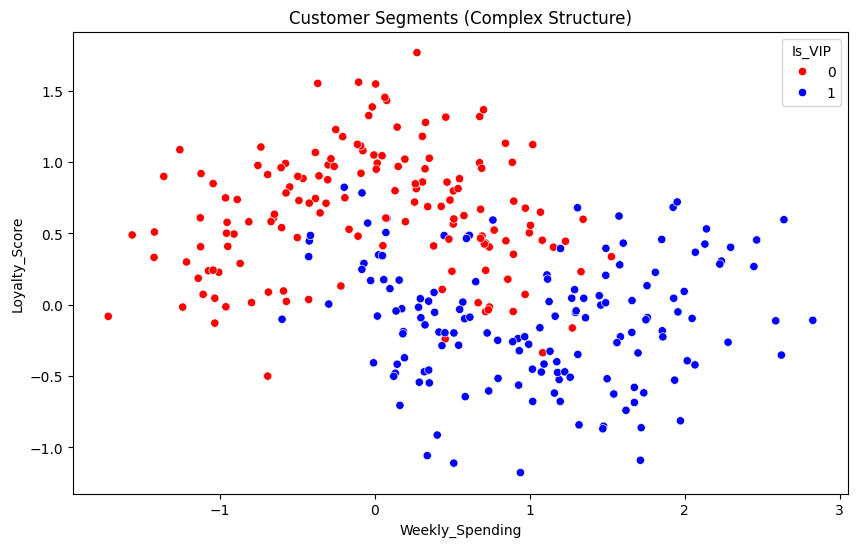

In [ ]:
import numpy as np  # Work with numbers
import pandas as pd  # Handle table-style data
import matplotlib.pyplot as plt  # Plot charts
import seaborn as sns  # Make nicer plots
from sklearn.model_selection import train_test_split  # Split data into train/test
from sklearn.tree import DecisionTreeClassifier  # Single decision tree model
from sklearn.ensemble import RandomForestClassifier  # Many trees working together
from sklearn.datasets import make_moons # Zorlu veri üretmek için  # Create tricky moon-shaped data

# 1. Data Generation (Interleaved crescent-shaped data)
 # Let's add some noise=0.3 to make the data a bit more realistic 
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)  # Create two-moon dataset
# A moon dataset is a classic example of a non-linear dataset that is not linearly separable.
# "Linearly separable" means you can draw a straight line (or plane in higher dimensions) to perfectly separate the two classes.
# Example: If all red points are on one side of a line and all blue points are on the other side, the data is linearly separable.
# The moon dataset curves in a crescent shape, so no single straight line can separate the two classes - it requires curved boundaries.

# Let's convert to DataFrame (for easier explanation and visualization)
df_forest = pd.DataFrame(X, columns=['Weekly_Spending', 'Loyalty_Score'])  # Name the two features
df_forest['Is_VIP'] = y  # Add target column

# 2. Visualization
plt.figure(figsize=(10, 6))  # Make a wide plot
sns.scatterplot(x='Weekly_Spending', y='Loyalty_Score', hue='Is_VIP', data=df_forest, palette=['red', 'blue'])  # Plot points colored by class
plt.title('Customer Segments (Complex Structure)')  # Title
plt.show()  # Display scatter plot

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # Split data

# 1. Single Decision Tree
tree_model = DecisionTreeClassifier(random_state=42)  # One tree model
tree_model.fit(X_train, y_train)  # Train the single tree

# 2. Random Forest (Ensemble of 100 trees)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)  # Many trees working together
rf_model.fit(X_train, y_train)  # Train the forest

print("Both models have been trained.")  # Confirm training

Both models have been trained.


In [3]:
from sklearn.metrics import accuracy_score  # Measure how often models are right

# Single Tree Score
tree_pred = tree_model.predict(X_test)  # Predictions from the single tree
tree_acc = accuracy_score(y_test, tree_pred)  # Accuracy of single tree

# Random Forest Score
rf_pred = rf_model.predict(X_test)  # Predictions from the forest
rf_acc = accuracy_score(y_test, rf_pred)  # Accuracy of forest

print(f"Single Tree Accuracy: %{tree_acc * 100:.2f}")  # Show single tree score
print(f"Random Forest Accuracy:   %{rf_acc * 100:.2f}")  # Show forest score

Single Tree Accuracy: %85.00
Random Forest Accuracy:   %88.33


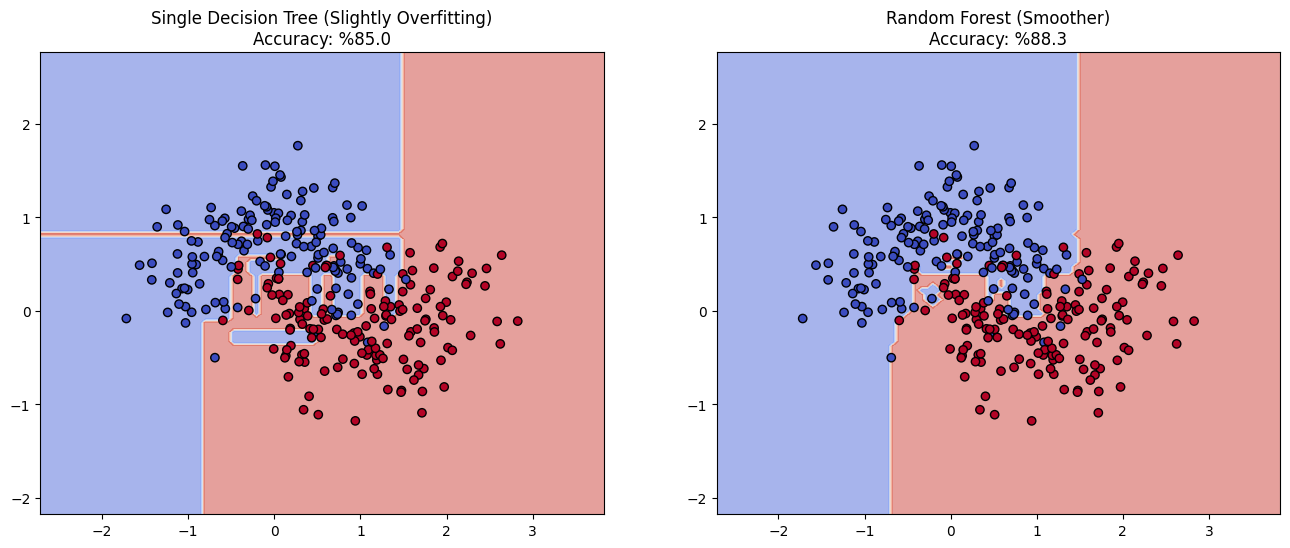

In [4]:
from sklearn.inspection import DecisionBoundaryDisplay  # Helper to draw class regions

fig, ax = plt.subplots(1, 2, figsize=(16, 6))  # Two side-by-side plots

# --- Graphic 1: Single Decision Tree ---
DecisionBoundaryDisplay.from_estimator(
    tree_model, X, cmap='coolwarm', alpha=0.5, ax=ax[0], response_method='predict'  # Regions from single tree
)
ax[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')  # Plot data points
ax[0].set_title(f'Single Decision Tree (Slightly Overfitting)\nAccuracy: %{tree_acc*100:.1f}')  # Title with score

# --- Graphic 2: Random Forest ---
DecisionBoundaryDisplay.from_estimator(
    rf_model, X, cmap='coolwarm', alpha=0.5, ax=ax[1], response_method='predict'  # Regions from forest
)
ax[1].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')  # Plot data points
ax[1].set_title(f'Random Forest (Smoother)\nAccuracy: %{rf_acc*100:.1f}')  # Title with score

plt.show()  # Display both plots

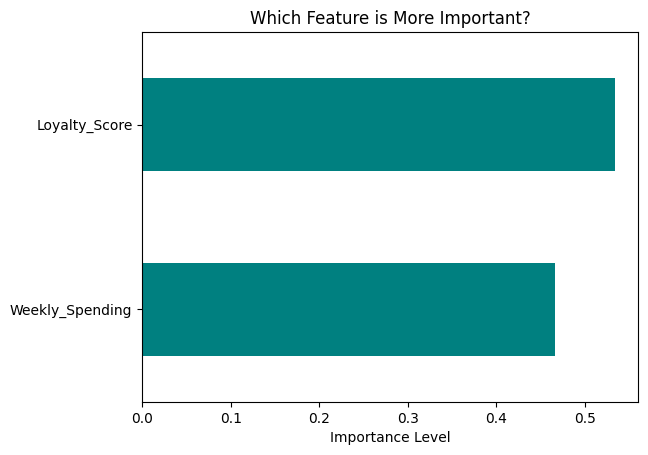

In [5]:
importances = pd.Series(rf_model.feature_importances_, index=['Weekly_Spending', 'Loyalty_Score'])  # Importance of each feature
importances.sort_values(ascending=True).plot(kind='barh', color='teal')  # Plot as horizontal bars
plt.title('Which Feature is More Important?')  # Title
plt.xlabel('Importance Level')  # Label x-axis
plt.show()  # Display the bar chart